### 1. 환경 세팅

In [ ]:
!pip install grad-cam matplotlib seaborn scikit-learn tensorflow keras

In [ ]:
# 1. ipywidgets 설치
!pip install ipywidgets

# 2. (선택사항) 주피터 랩/노트북 확장 활성화 - 최신 버전은 자동으로 되지만 안 될 경우 실행
!jupyter nbextension enable --py widgetsnbextension

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


### 2. 모델 불러오기

In [8]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1. 모델 파일 경로 설정
MODEL_PATH = "cnn_baseline_best.h5"

# 2. 파일 존재 여부 확인
if os.path.exists(MODEL_PATH):
    print(f"✅ 모델 파일을 찾았습니다: {MODEL_PATH}")
    
    try:
        # 3. Keras 모델 로드 (compile=False로 설정하여 버전 불일치 에러 방지)
        # 이전 버전에서 저장된 loss 설정(reduction='auto')과의 충돌을 피합니다.
        model = load_model(MODEL_PATH, compile=False)
        print("🚀 Keras CNN 모델 구조 및 가중치 로드 완료!")

        # 4. 모델 재컴파일 (현재 환경에 맞는 설정 적용)
        # 만약 분류(Classification) 모델이라면 아래 설정을 유지하세요.
        # 이진 분류라면 loss='binary_crossentropy', 다중 분류라면 'categorical_crossentropy'
        model.compile(optimizer='adam', 
                      loss='sparse_categorical_crossentropy', 
                      metrics=['accuracy'])
        print("✅ 모델 재컴파일 완료! 이제 즉시 사용 가능합니다.")
        
        # 모델 구조 확인
        model.summary()

    except Exception as e:
        print(f"❌ 모델 로드 중 오류 발생: {e}")

else:
    print(f"❌ 모델 파일이 없습니다! 경로를 확인해주세요: {os.getcwd()}")

✅ 모델 파일을 찾았습니다: cnn_baseline_best.h5
🚀 Keras CNN 모델 구조 및 가중치 로드 완료!
✅ 모델 재컴파일 완료! 이제 즉시 사용 가능합니다.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,080,579 (99.49 MB)

 Trainable params: 26,080,579 (99.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# 1. 데이터 경로 설정 
TEST_DIR = '../../../../data/test' 

# 2. 전처리 설정 
IMG_SIZE = 256
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    # ImageNet 표준 정규화 값
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 3. 데이터셋 및 로더(제너레이터) 생성
try:
    test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
    
    # 변수명을 test_loader 대신 test_generator로 설정하여 이후 코드와의 호환성 확보
    test_generator = DataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"✅ 데이터를 성공적으로 불러왔습니다.")
    print(f"클래스 목록: {test_dataset.classes}")
    print(f"테스트 이미지 개수: {len(test_dataset)}개")
    
except FileNotFoundError:
    print(f"❌ '{TEST_DIR}' 경로를 찾을 수 없습니다. 현재 경로: {os.getcwd()}")

✅ 데이터를 성공적으로 불러왔습니다.
클래스 목록: ['cat', 'dog', 'fox']
테스트 이미지 개수: 464개


### 3. 테스트 & 시각화

🚀 실전 테스트 중... (Test Set 평가)


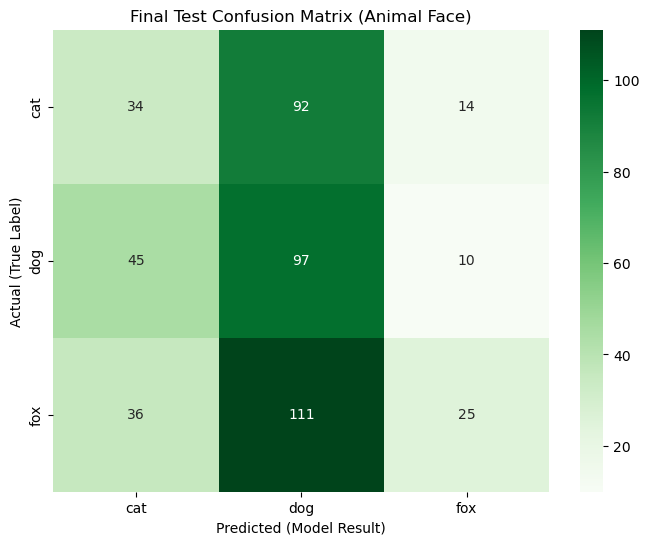


[ 최종 성능 리포트 ]
              precision    recall  f1-score   support

         cat       0.30      0.24      0.27       140
         dog       0.32      0.64      0.43       152
         fox       0.51      0.15      0.23       172

    accuracy                           0.34       464
   macro avg       0.38      0.34      0.31       464
weighted avg       0.38      0.34      0.30       464



In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report

def plot_test_confusion_matrix(model, generator):
    print("🚀 실전 테스트 중... (Test Set 평가)")
    
    all_preds = []
    all_labels = []
    
    # PyTorch DataLoader에서 데이터를 배치 단위로 꺼내기
    for images, labels in generator:
        # 1. 차원 변경: (Batch, Channel, H, W) -> (Batch, H, W, Channel)
        # TensorFlow 모델이 이해할 수 있는 형태로 변환합니다.
        images_tf = images.permute(0, 2, 3, 1).numpy()
        
        # 2. 예측 수행
        preds = model.predict(images_tf, verbose=0)
        all_preds.extend(np.argmax(preds, axis=1))
        all_labels.extend(labels.numpy())
    
    y_pred = np.array(all_preds)
    y_true = np.array(all_labels)
    
    # 3. 클래스 이름 가져오기 (PyTorch Dataset 기준)
    class_names = generator.dataset.classes

    # 4. 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred)
    
    # 5. 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Final Test Confusion Matrix (Animal Face)')
    plt.ylabel('Actual (True Label)')
    plt.xlabel('Predicted (Model Result)')
    plt.show()
    
    # 6. 상세 리포트 출력
    print("\n[ 최종 성능 리포트 ]")
    print(classification_report(y_true, y_pred, target_names=class_names))

# 실행
if 'test_generator' in locals():
    plot_test_confusion_matrix(model, test_generator)
else:
    print("⚠️ test_generator가 없습니다. 이전 단계의 데이터 로드 코드를 먼저 실행해주세요.")

📸 테스트 이미지 정성적 평가를 시작합니다...


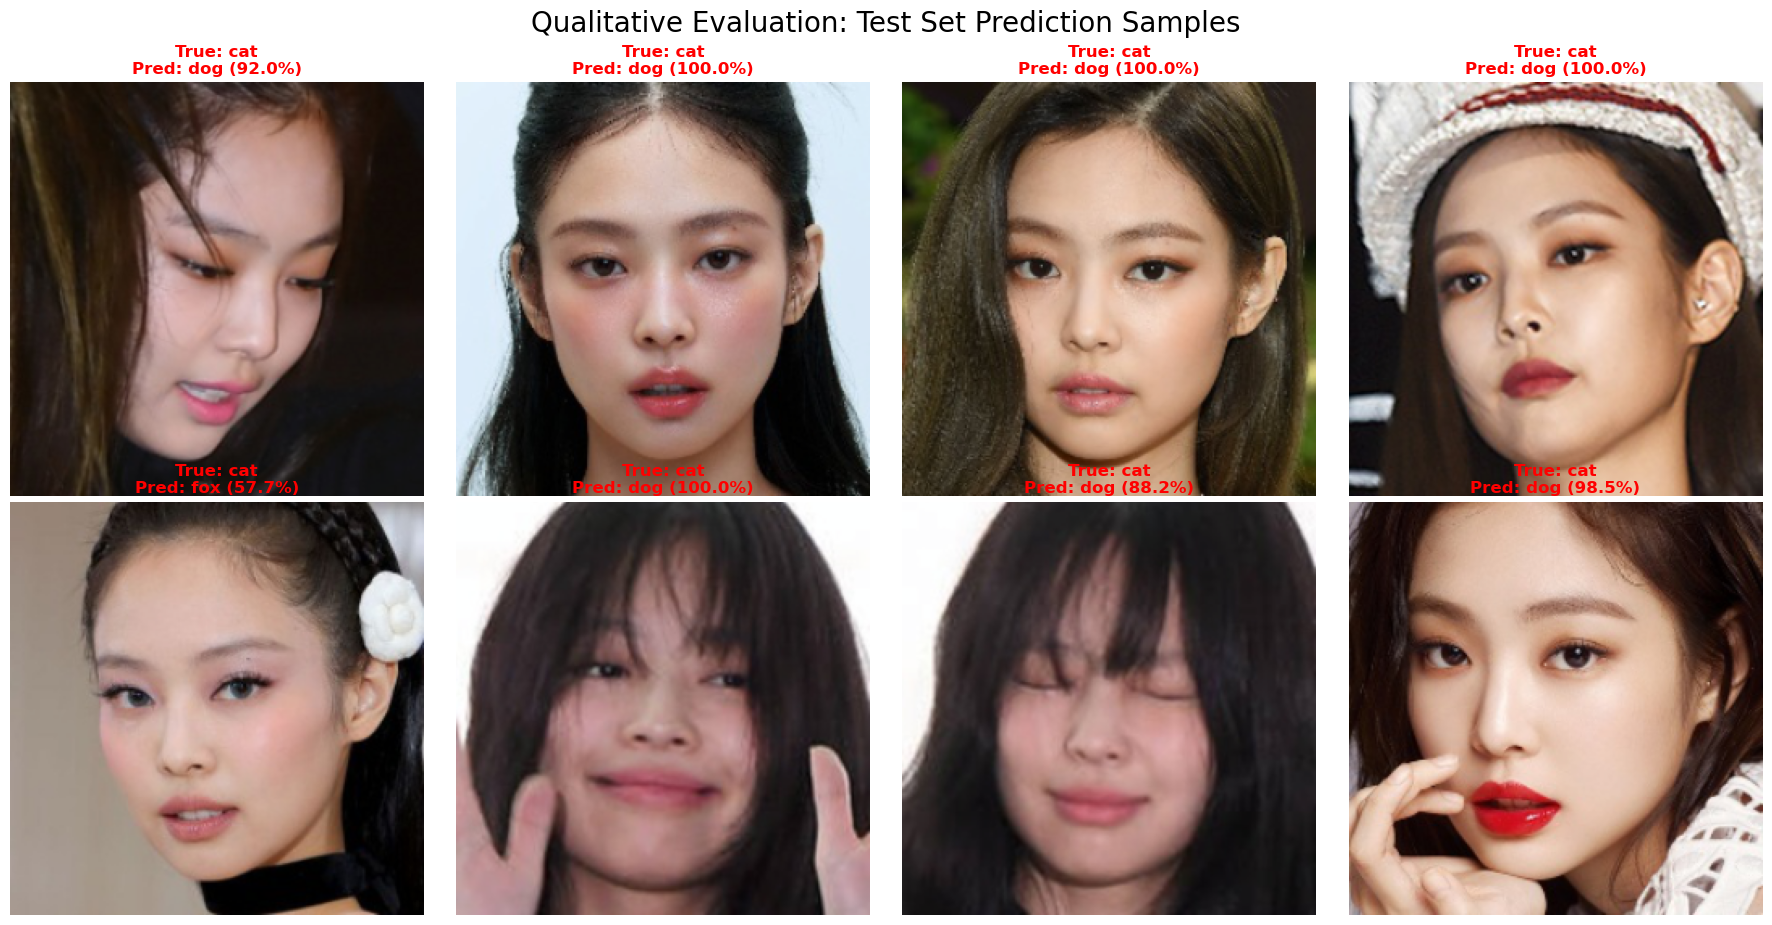

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def denormalize(tensor):
    """
    전처리(Normalize)된 텐서를 시각화를 위해 원본 색상으로 복구합니다.
    ImageNet 표준 평균(mean)과 표준편차(std)를 사용합니다.
    """
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # 전계산: (H, W, C) 형태의 넘파이 배열에 std를 곱하고 mean을 더함
    img = tensor * std + mean
    return np.clip(img, 0, 1) # 0~1 범위를 벗어나는 값 보정

def visualize_test_results(model, generator, num_images=8):
    print("📸 테스트 이미지 정성적 평가를 시작합니다...")
    
    # 1. 데이터 로더에서 한 배치 가져오기
    images, labels = next(iter(generator))
    
    # 클래스 이름 리스트 추출
    class_names = generator.dataset.classes
    
    # 2. 모델 예측 수행 (TensorFlow 모델용 차원 변경)
    # PyTorch (B, C, H, W) -> TensorFlow (B, H, W, C)
    images_tf = images.permute(0, 2, 3, 1).numpy()
    preds = model.predict(images_tf, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    
    # 3. 시각화 설정 (2x4 격자)
    plt.figure(figsize=(18, 10))
    
    for i in range(num_images):
        plt.subplot(2, 4, i + 1)
        
        # [핵심] 역정규화를 통해 필터 현상 제거 및 색상 복원
        img_display = denormalize(images_tf[i])
        
        plt.imshow(img_display)
        
        # 실제값(True)과 예측값(Pred) 비교
        true_name = class_names[labels[i]]
        pred_name = class_names[pred_labels[i]]
        
        # 맞으면 파란색, 틀리면 빨간색으로 표시
        color = 'blue' if true_name == pred_name else 'red'
        
        # 예측 확률(Confidence) 계산 (선택 사항)
        confidence = np.max(preds[i]) * 100
        
        plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)", 
                  color=color, fontsize=12, fontweight='bold')
        plt.axis('off')
    
    plt.suptitle("Qualitative Evaluation: Test Set Prediction Samples", fontsize=20, y=0.95)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 실행 부분
if 'model' in locals() and 'test_generator' in locals():
    visualize_test_results(model, test_generator, num_images=8)
else:
    print("⚠️ model 또는 test_generator 변수가 메모리에 없습니다. 이전 단계 코드를 먼저 실행해 주세요.")